<a href="https://colab.research.google.com/github/msiplab/EicEngLabIV/blob/master/example01_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 実験Ⅳ－１　線形単回帰モデル

新潟大学工学部工学科　電子情報通信プログラム

## 準備

In [1]:
!pip install japanize-matplotlib
%matplotlib inline

import warnings
warnings.simplefilter('ignore') #警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib #日本語化matplotlib
sns.set(font="IPAexGothic") #日本語フォント設定


In [2]:
def load_voltage(current):
  """
  電源モデル
  出力電流と負荷電圧の関係
  """
  # 電源電圧
  source_voltage = 24 # [V]
  # 内部抵抗
  internal_register = 2 # [Ω]
  # 負荷電圧
  return source_voltage - internal_register * current

## 観測データ（ノイズなし）

In [3]:
# 表1の観測データ（固定値）
I_all = np.array([0.614, 0.007, 0.566, 0.604, 0.480, 0.440, 0.804, 0.115], dtype=float)
V_all = np.array([22.308, 23.603, 22.853, 22.542, 22.687, 22.652, 22.337, 23.101], dtype=float)

# (1) 任意の2組を選択（0始まりのインデックス）
idx_pair = [0, 1]

# 選択した2点データ
current_observations = I_all[idx_pair]
load_voltages = V_all[idx_pair]

# 観測点数
nSamples = len(current_observations)

## 散布図の表示


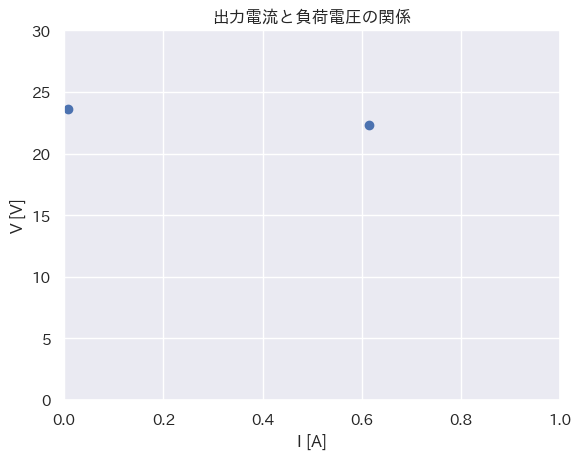

In [4]:
#散布図の表示
fig, ax = plt.subplots()
ax.scatter(current_observations,load_voltages)
ax.set_title("出力電流と負荷電圧の関係")
ax.set_xlabel("I [A]")
ax.set_ylabel("V [V]")
ax.set_xlim([0,1])
ax.set_ylim([0,30])
ax.grid(True)
plt.show()

## 電源電圧 $E$ と内部抵抗 $r$ の解

連立方程式は、Numpy ライブラリにある linalg.solve で解くことができる。

データセット$\{(\mathrm{I}_1,\mathrm{V}_1),(\mathrm{I}_2,\mathrm{V}_2)\}$より，

$\left(\begin{array}{l}E \\ r\end{array}\right)=\left(\begin{array}{ll}1 & -\mathrm{I}_{1} \\ 1 & -\mathrm{I}_{2}\end{array}\right)^{-1}\left(\begin{array}{l}\mathrm{V}_{1} \\ \mathrm{V}_{2}\end{array}\right)$

In [5]:
X = np.array([[1.0, -current_observations[0]],
              [1.0, -current_observations[1]]])
y = np.array([load_voltages[0], load_voltages[1]])
beta = np.linalg.solve(X, y)

print("選択したデータ番号 n =", [idx + 1 for idx in idx_pair])
print("電源電圧 E = {0:5.3f} [V]".format(float(beta[0])))
print("内部抵抗 r = {0:5.3f} [Ω]".format(float(beta[1])))

選択したデータ番号 n = [1, 2]
電源電圧 E = 23.618 [V]
内部抵抗 r = 2.133 [Ω]


# 観測データ（表1の8点）

In [6]:
# 観測点数
nSamples = len(I_all)

# 表1の全8点データ
current_observations = I_all
load_voltages = V_all

# 観測データの表
dataset = pd.DataFrame({'I[A]': current_observations,
                        'V[V]': load_voltages})
dataset.index += 1  # インデックスを1から付与
display(dataset)

,I[A],V[V]
1,0.614,22.308
2,0.007,23.603
3,0.566,22.853
4,0.604,22.542
5,0.480,22.687
6,0.440,22.652
7,0.804,22.337
8,0.115,23.101


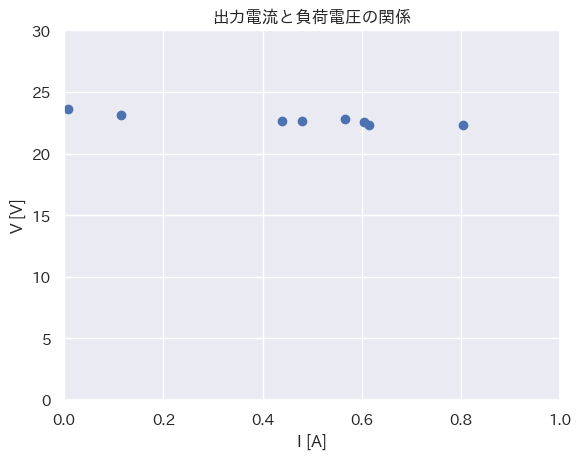

In [7]:
#散布図の表示
fig, ax = plt.subplots()
ax.scatter(current_observations,load_voltages)
ax.set_title("出力電流と負荷電圧の関係")
ax.set_xlabel("I [A]")
ax.set_ylabel("V [V]")
ax.set_xlim([0,1])
ax.set_ylim([0,30])
ax.grid(True)
plt.show()

## 電源電圧 $E$ と内部抵抗 $r$ の推定

8点すべての観測データから、ムーア・ペンローズ擬似逆行列で推定する。

$$
\begin{aligned}
\begin{bmatrix}\hat{E}\\\hat{r}\end{bmatrix}
&= \mathbf{X}^{+}\mathbf{y}, \\
\mathbf{X} &= \begin{bmatrix}
1 & -I_1 \\
1 & -I_2 \\
\vdots & \vdots \\
1 & -I_N
\end{bmatrix}, \quad
\mathbf{y} = \begin{bmatrix}
V_1\\V_2\\\vdots\\V_N
\end{bmatrix}
\end{aligned}
$$

電源電圧の推定値 E^ = 23.429 [V]
内部抵抗の推定値 r^ = 1.475 [Ω]


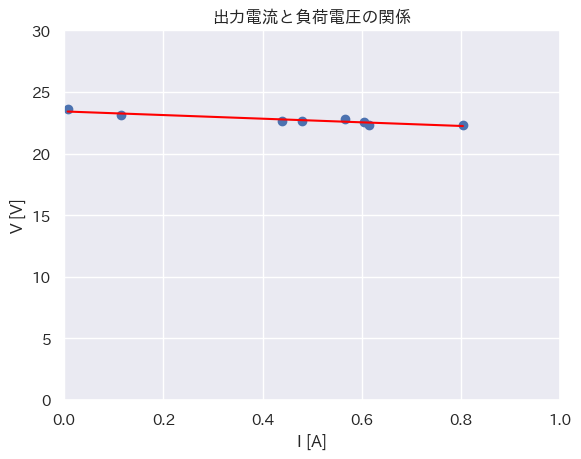

In [8]:
# 説明変数行列 X と目的変数 y
X = np.c_[np.ones(nSamples), -current_observations]
y = load_voltages

# ムーア・ペンローズ擬似逆行列による推定
beta = np.linalg.pinv(X) @ y
Ehat = beta[0]
rhat = beta[1]
print("電源電圧の推定値 E^ = {0:5.3f} [V]".format(float(Ehat)))
print("内部抵抗の推定値 r^ = {0:5.3f} [Ω]".format(float(rhat)))

# 推定直線をプロット
ifit = np.linspace(np.min(current_observations), np.max(current_observations), 200)
vfit = Ehat - rhat * ifit

fig, ax = plt.subplots()
ax.scatter(current_observations, load_voltages)
ax.plot(ifit, vfit, color='red')
ax.set_title("出力電流と負荷電圧の関係")
ax.set_xlabel("I [A]")
ax.set_ylabel("V [V]")
ax.set_xlim([0, 1])
ax.set_ylim([0, 30])
ax.grid(True)
plt.show()